# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, multilabel_confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

## Leemos nuestro archivo de entrada `reviews_sentiment`

In [ ]:
#pd.set_option('max_colwidth', None)

In [6]:
# lee los datos de 'data/reviews_sentiment.csv'
# df

df = pd.read_csv('./data/reviews_sentiment.csv', sep=';', encoding='utf-8')
df.head()

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784


Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

In [7]:
# haz un info del df

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    str    
 1   Review Text     257 non-null    str    
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    str    
 4   textSentiment   257 non-null    str    
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), str(4)
memory usage: 29.3 KB


In [ ]:
# haz un describe del df

df.describe()

,wordcount,Star Rating,sentimentValue
count,257.000000,257.000000,257.000000
mean,11.501946,3.420233,0.383849
std,13.159812,1.409531,0.897987
min,1.000000,1.000000,-2.276469
25%,3.000000,3.000000,-0.108144
50%,7.000000,3.000000,0.264091
75%,16.000000,5.000000,0.808384
max,103.000000,5.000000,3.264579


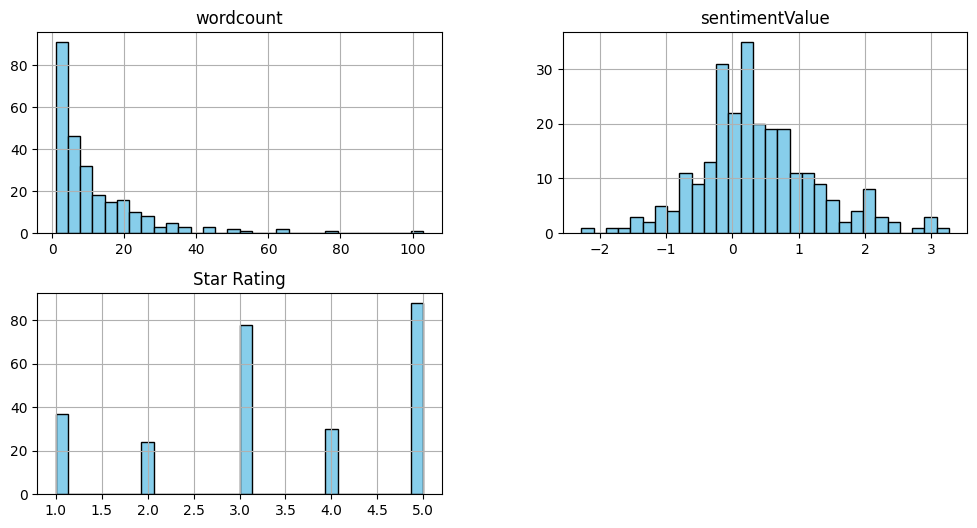

In [25]:
# calcula los histogramas del df

df[['wordcount', 'sentimentValue', 'Star Rating']].hist(bins=30, figsize=(12, 6), color='skyblue', edgecolor='black')
plt.show()

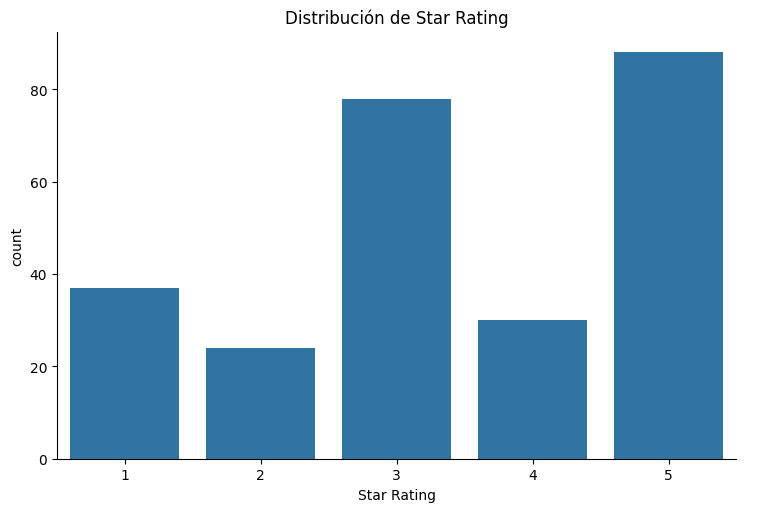

In [26]:
# haz un catplot del star rating

sns.catplot(x='Star Rating', kind='count', data=df, height=5, aspect=1.5)
plt.title('Distribución de Star Rating')
plt.show()

In [27]:
# haz un value counts del star rating

df['Star Rating'].value_counts(normalize=True)

Star Rating
5    0.342412
3    0.303502
1    0.143969
4    0.116732
2    0.093385
Name: proportion, dtype: float64

In [9]:
# imblearn

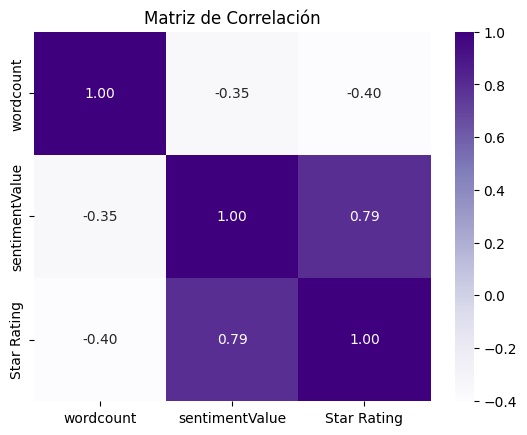

In [21]:
# haz un heatmap de la matriz de correlación

corr = df[['wordcount', 'sentimentValue', 'Star Rating']].corr()
sns.heatmap(corr, annot=True, cmap='Purples', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [28]:
#
# X es wordcount y sentimentValue
# y es Star Rating

# haz un train_test_split
# muestra los shape de X train, X test, y train, y test

X = df[['wordcount', 'sentimentValue']]
y = df['Star Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(205, 2)
(52, 2)
(205,)
(52,)


In [ ]:
# haz un minmaxscaler y úsalo con X train y con Xtest
# calcula los mínimos y máximos en X train y en X test

scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

print(f"Min Train: {X_train_mm.min()}")
print(f"Max Train: {X_train_mm.max()}")
print(f"Min Test:  {X_test_mm.min()}")
print(f"Max Test:  {X_test_mm.max()}")

Min Train: 0.0
Max Train: 1.0
Min Test:  -0.0982228016602878
Max Test:  0.9325760278023711


In [30]:
# equivalente pero con StandardScaler

scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

print(f"Mean Train: {X_train_std.mean():.4f}")
print(f"Std Train:  {X_train_std.std():.4f}")
print(f"Mean Test:  {X_test_std.mean():.4f}")
print(f"Std Test:   {X_test_std.std():.4f}")

Mean Train: 0.0000
Std Train:  1.0000
Mean Test:  0.0095
Std Test:   1.1282


## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [31]:
# importa el knn clasiffier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_mm, y_train)

y_train_pred = knn.predict(X_train_mm)
y_test_pred = knn.predict(X_test_mm)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Train Error:    {1 - accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test Error:     {1 - accuracy_score(y_test, y_test_pred):.4f}")

Train Accuracy: 0.9415
Train Error:    0.0585
Test Accuracy:  0.8269
Test Error:     0.1731


## Evalúa tu modelo

In [32]:
# predice con X test escalado
# calcula el accuracy en test y la matriz de confusión en test

print(confusion_matrix(y_test, y_test_pred))

[[ 8  2  0  0  0]
 [ 0  2  0  0  0]
 [ 3  0 11  0  0]
 [ 0  1  0  3  3]
 [ 0  0  0  0 19]]


In [33]:

# calcula la multilabel confusion matriz en test

print(multilabel_confusion_matrix(y_test, y_test_pred))

[[[39  3]
  [ 2  8]]

 [[47  3]
  [ 0  2]]

 [[38  0]
  [ 3 11]]

 [[45  0]
  [ 4  3]]

 [[30  3]
  [ 0 19]]]


In [34]:
# calcula el classification report en test

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           1       0.73      0.80      0.76        10
           2       0.40      1.00      0.57         2
           3       1.00      0.79      0.88        14
           4       1.00      0.43      0.60         7
           5       0.86      1.00      0.93        19

    accuracy                           0.83        52
   macro avg       0.80      0.80      0.75        52
weighted avg       0.87      0.83      0.82        52



In [ ]:

# predice los puntos originales [[10,3],[3,-2]]



c:\Users\Alberto Romero\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([5, 1])

## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

In [35]:
# sin usar gridsearchcv, prueba valores de k entre 1 y 30
# usa un bucle for, entrena el modelo y calcula el score en test

k_range = range(1, 31, 3)
train_scores = []
test_scores = []

for k in k_range:
    knn_loop = KNeighborsClassifier(n_neighbors=k)
    knn_loop.fit(X_train_mm, y_train)
    train_scores.append(accuracy_score(y_train, knn_loop.predict(X_train_mm)))
    test_scores.append(accuracy_score(y_test, knn_loop.predict(X_test_mm)))

print(f"Mejor k: {k_range[np.argmax(test_scores)]} con accuracy test: {max(test_scores):.4f}")

Mejor k: 1 con accuracy test: 0.8269


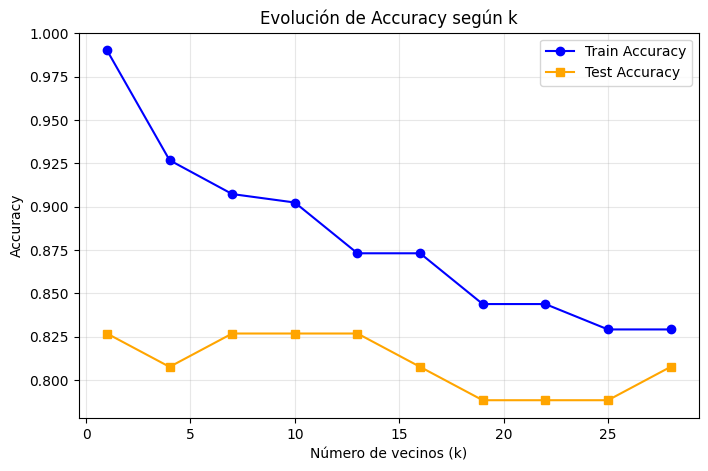

In [37]:
# con un scatter plot pinta para cada k su score en test

plt.figure(figsize=(8, 5))
plt.plot(k_range, train_scores, marker='o', label='Train Accuracy', color='blue')
plt.plot(k_range, test_scores, marker='s', label='Test Accuracy', color='orange')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Accuracy')
plt.title('Evolución de Accuracy según k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# EXTRA

# usa pipeline y gridsearchcv

# importa los módulos

In [47]:
# Haz un pipeline con pasos: minmaxscaler y luego knn classifier

pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('classifier', KNeighborsClassifier())
])



In [48]:
# hiperparámetros

params = {
    'scaler': [MinMaxScaler(), StandardScaler(), None],
    'classifier__n_neighbors': np.arange(2,15),
    'classifier__weights': ['uniform', 'distance']
}

In [49]:
gs_pipe = GridSearchCV(pipe, params, cv=5, scoring='accuracy', verbose=1)
gs_pipe.fit(X_train, y_train)
print(gs_pipe.best_estimator_)
print(gs_pipe.best_params_)
print(gs_pipe.best_score_)

Fitting 5 folds for each of 78 candidates, totalling 390 fits
Pipeline(steps=[('scaler', MinMaxScaler()),
                ('classifier', KNeighborsClassifier(n_neighbors=np.int64(7)))])
{'classifier__n_neighbors': np.int64(7), 'classifier__weights': 'uniform', 'scaler': MinMaxScaler()}
0.8878048780487806


In [50]:
h_model = gs_pipe.best_estimator_
h_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(7)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=3

In [51]:
h_model.fit(X_train, y_train)
y_pred = h_model.predict(X_test)
print("accuracy_score", accuracy_score(y_test, y_pred))

accuracy_score 0.8269230769230769


In [52]:
h_model['classifier']

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(7)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [53]:
h_model['scaler']

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [54]:
h_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(7)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=3

In [57]:
# predice el punto [5,1]

nuevo_punto = pd.DataFrame([[5, 1]], columns=['wordcount', 'sentimentValue'])


prediccion = h_model.predict(nuevo_punto)
print(f"Predicción para {nuevo_punto}: {prediccion[0]} estrella(s)")

Predicción para    wordcount  sentimentValue
0          5               1: 5 estrella(s)
